In [88]:
#preserved concepts
import concept_getters
import pandas as pd
import re
SPARSITY_RATIOS_LTH = [0.0, 20.0, 36.0, 48.8, 59.04, 67.232, 73.786, 79.028, 83.223, 86.578, 89.263, 91.41, 93.128, 94.502]
SPARSITY_RATIOS_WANDA = [0.0, 19.987, 35.97, 48.796, 59.017, 67.22, 73.763, 79.004, 83.203, 86.556, 89.258, 91.406, 93.099, 94.499]

import collections

def get_indiv_concepts_per_unit(df) -> dict:
    concepts = {}
    for unit,expl in zip(df.unit, df.best_name):
        concps = re.findall(r'(?<!\bNOT\s)(?:\b(?:hyp|pre|oth):[^\s)]+)', expl)
        for i in range(len(concps)):
            while concps[i][-1] == ')':
                concps[i] = concps[i][:-1]
        concepts[unit] = concps
    return concepts

def get_concepts_across_pruning_per_neuron(model, method, filename):
    explanations = collections.defaultdict(list)
    sparsity_list = sorted(os.listdir(f"/workspace/CCE_NLI/{model}/exp/{method}/{filename}/Expls/"))
    for sparsity in sparsity_list:
        if '.ipy' in sparsity: continue
        sparsity = sparsity.split("%")[0]
        cluster3_expls = pd.read_csv(f"/workspace/CCE_NLI/{model}/exp/{method}/{filename}/Expls/{sparsity}%Pruned/Cluster3IOUS1024N.csv")
        explanations[float(sparsity)] = get_indiv_concepts_per_unit(cluster3_expls) 
    reordered = collections.defaultdict(dict)
    for sparsity, neurons in explanations.items():
        for neuron, concepts in neurons.items():
            reordered[neuron][sparsity] = concepts
    return reordered 

def get_concepts_assoc_sparsities(model, method, filename):
    explanations = collections.defaultdict(list)
    sparsity_list = sorted(os.listdir(f"/workspace/CCE_NLI/{model}/exp/{method}/{filename}/Expls/"))
    for sparsity in sparsity_list:
        if '.ipy' in sparsity: continue
        sparsity = sparsity.split("%")[0]
        cluster3_expls = pd.read_csv(f"/workspace/CCE_NLI/{model}/exp/{method}/{filename}/Expls/{sparsity}%Pruned/Cluster3IOUS1024N.csv")
        explanations[float(sparsity)] = get_indiv_concepts_per_unit(cluster3_expls) 
    reordered = collections.defaultdict(lambda: collections.defaultdict(set))
    for sparsity, neurons in explanations.items():
        for neuron, concepts in neurons.items():
            for concept in concepts:
                reordered[neuron][concept].add(sparsity)
    return reordered 

In [2]:
def count_frequencies(concepts_dict, neuron):
    concept_freq = []
    for list_of_concepts in concepts_dict[neuron].values():
        concept_freq.extend(list_of_concepts)
    concept_freq = collections.Counter(concept_freq)
    return {concept: freq for concept, freq in concept_freq.items() if freq > 5}
        
unique_concepts =set()
def num_unique_concepts_for_a_neuron(concepts_dict, neuron):
    concept_freq = []
    for list_of_concepts in concepts_dict[neuron].values():
        concept_freq.extend(list_of_concepts)
    concept_freq = collections.Counter(concept_freq)
    for concept in concept_freq:
        unique_concepts.add()
    return {concept: freq for concept, freq in concept_freq.items() if freq > 5}
                
        
        

In [3]:
list_of_repeated_concepts = set()

for neuron in reordered.keys():
    frequencies = count_frequencies(reordered,neuron)
    concepts = list(frequencies.keys())
    for c in concepts:
        list_of_repeated_concepts.add(c)


NameError: name 'reordered' is not defined

In [4]:
len(list_of_repeated_concepts) 
#across all neurons and all iterations, 160 concepts repeat within a neuron at least 5 times 
#(meaning across 1024 neurons there are 106 uniue concepts where across pruning they are dominant 5/14 iterations ) 
#doesnt show whether they're dominant in begining/middle/end just that they're preserved 30% of iters for at least 1 neuron

0

In [5]:
#graph for each neuron on avg how many concepts are repeated % of times
list_of_repeated_concepts = set()
unique = 0
for neuron in reordered.keys():
    frequencies = count_frequencies(reordered,neuron)
    num_u = num_unique_concepts_for_a_neuron(reordered,neuron)
    unique+=len(num_u)
    
    concepts = list(frequencies.keys())
num_u

NameError: name 'reordered' is not defined

# neuron wise: % of concepts preserved for at least first k iters
so for first 1 iters (ie only 1 iter 0.0%), should be 1.0 (all concepts are preserved for at least 1 iter)

'model="BOWMAN"\nbowman_dropoffs_lth = []\nmethod = \'lottery_ticket\'\nfilename = \'Run2Full\'\nsparsity_list = SPARSITY_RATIOS_LTH\nfor k in range(1,15):\n    num_orig_cps = get_num_concpets_explained_originally(method, filename)\n    neuron_concept_sparsity_mapping = get_concepts_across_pruning_per_neuron(model, method, filename)\n    concept_assoc_sparsity=get_concepts_assoc_sparsities(model, method, filename)\n    percent_of_concepts_preserved = dropoff(method, filename, k, num_orig_cps=num_orig_cps, concept_assoc_sparsity= concept_assoc_sparsity,neuron_concept_sparsity_mapping=neuron_concept_sparsity_mapping)\n    bowman_dropoffs_lth.append(percent_of_concepts_preserved)\n    \n    \nbowman_dropoffs_wanda = []\nmethod = \'wanda\'\nfilename = \'Run2Full\'\nsparsity_list = SPARSITY_RATIOS_WANDA\nfor k in range(1,15):\n    num_orig_cps = get_num_concpets_explained_originally(method, filename)\n    neuron_concept_sparsity_mapping = get_concepts_across_pruning_per_neuron(model, method

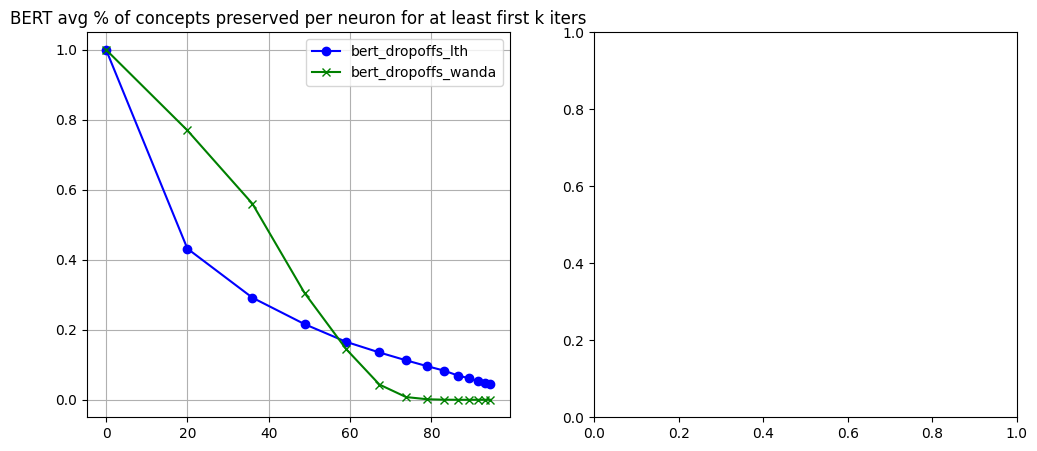

In [159]:
import matplotlib.pyplot as plt

def get_num_concpets_explained_originally(method, filename):
    unique_concepts=set()
    explanations = {}
    cluster3_expls = pd.read_csv(f"/workspace/CCE_NLI/{model}/exp/{method}/{filename}/Expls/{0.0}%Pruned/Cluster3IOUS1024N.csv")
    all_concept_at_original = get_indiv_concepts_per_unit(cluster3_expls) 
    for neuron, concepts in all_concept_at_original.items():
        for concept in concepts:
            unique_concepts.add(concept)
    return len(unique_concepts) 



def dropoff(method, filename, k, **kwargs):
        
    num_orig_cps = kwargs['num_orig_cps']
    concept_and_assoc_sparsities = kwargs['concept_assoc_sparsity']
    sparsity_mapping = kwargs['neuron_concept_sparsity_mapping']
    
    percent_cocnepts_preserved=[]
    for neuron in sparsity_mapping.keys():
        concepts_preserved=set()
        for concept in concept_and_assoc_sparsities[neuron]:
            list_of_concepts_and_sprsty = list(concept_and_assoc_sparsities[neuron][concept])
            first_k_iters_present = sorted(list_of_concepts_and_sprsty)[:k]
            if first_k_iters_present == sparsity_list[:k]: #this concept is preserved for at lesat the first 6 iters
                concepts_preserved.add(concept)
        #print(neuron, len(concepts_preserved), len(sparsity_mapping[neuron][0.0]))
        if 0.0 in sparsity_mapping[neuron].keys():
            percent_cocnepts_preserved.append(len(concepts_preserved)/len(sparsity_mapping[neuron][0.0]))
        
    return sum(percent_cocnepts_preserved)/len(percent_cocnepts_preserved)
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
x=[SPARSITY_RATIOS_WANDA[i] for i in range(0,14)] 

model="BERT"
bert_dropoffs_lth = []
method = 'lottery_ticket'
filename = 'Run2Full'
sparsity_list = SPARSITY_RATIOS_LTH
for k in range(1,15):
    num_orig_cps = get_num_concpets_explained_originally(method, filename)
    neuron_concept_sparsity_mapping = get_concepts_across_pruning_per_neuron(model, method, filename)
    concept_assoc_sparsity=get_concepts_assoc_sparsities(model, method, filename)
    percent_of_concepts_preserved = dropoff(method, filename, k, num_orig_cps=num_orig_cps, concept_assoc_sparsity= concept_assoc_sparsity,neuron_concept_sparsity_mapping=neuron_concept_sparsity_mapping)
    bert_dropoffs_lth.append(percent_of_concepts_preserved)
    
    
bert_dropoffs_wanda = []
method = 'wanda'
filename = 'Run2Full'
sparsity_list = SPARSITY_RATIOS_WANDA
for k in range(1,15):
    num_orig_cps = get_num_concpets_explained_originally(method, filename)
    neuron_concept_sparsity_mapping = get_concepts_across_pruning_per_neuron(model, method, filename)
    concept_assoc_sparsity=get_concepts_assoc_sparsities(model, method, filename)
    percent_of_concepts_preserved = dropoff(method, filename, k, num_orig_cps=num_orig_cps, concept_assoc_sparsity= concept_assoc_sparsity,neuron_concept_sparsity_mapping=neuron_concept_sparsity_mapping)
    bert_dropoffs_wanda.append(percent_of_concepts_preserved)
    

axs[0].plot(x, bert_dropoffs_lth, label='bert_dropoffs_lth', color='blue',marker='o')
axs[0].plot(x, bert_dropoffs_wanda, label='bert_dropoffs_wanda', color='green',marker='x')
axs[0].set_title('BERT avg % of concepts preserved per neuron for at least first k iters')
axs[0].legend()
axs[0].grid(True)


'''model="BOWMAN"
bowman_dropoffs_lth = []
method = 'lottery_ticket'
filename = 'Run2Full'
sparsity_list = SPARSITY_RATIOS_LTH
for k in range(1,15):
    num_orig_cps = get_num_concpets_explained_originally(method, filename)
    neuron_concept_sparsity_mapping = get_concepts_across_pruning_per_neuron(model, method, filename)
    concept_assoc_sparsity=get_concepts_assoc_sparsities(model, method, filename)
    percent_of_concepts_preserved = dropoff(method, filename, k, num_orig_cps=num_orig_cps, concept_assoc_sparsity= concept_assoc_sparsity,neuron_concept_sparsity_mapping=neuron_concept_sparsity_mapping)
    bowman_dropoffs_lth.append(percent_of_concepts_preserved)
    
    
bowman_dropoffs_wanda = []
method = 'wanda'
filename = 'Run2Full'
sparsity_list = SPARSITY_RATIOS_WANDA
for k in range(1,15):
    num_orig_cps = get_num_concpets_explained_originally(method, filename)
    neuron_concept_sparsity_mapping = get_concepts_across_pruning_per_neuron(model, method, filename)
    concept_assoc_sparsity=get_concepts_assoc_sparsities(model, method, filename)
    percent_of_concepts_preserved = dropoff(method, filename, k, num_orig_cps=num_orig_cps, concept_assoc_sparsity= concept_assoc_sparsity,neuron_concept_sparsity_mapping=neuron_concept_sparsity_mapping)
    bowman_dropoffs_wanda.append(percent_of_concepts_preserved)
    


axs[1].plot(x, bowman_dropoffs_lth, label='bowman_dropoffs_lth', color='blue',marker='o')
axs[1].plot(x, bowman_dropoffs_wanda, label='bowman_dropoffs_wanda', color='green',marker='x')
axs[1].set_title('BOWMAN neuron wise: % of concepts preserved for at least first k iters')
axs[1].legend()
axs[1].grid(True)'''
    
    

#so ex 30% of concepts make it to the 3rd pruning iter staying with the same neuron
    
  

# % of neurons that preserve concepts for at lesat first k iters

"axs[1].plot(x, bowman_dropoffs_lth, label='bowman_dropoffs_lth', color='blue',marker='o')\naxs[1].plot(x, bowman_dropoffs_wanda, label='bowman_dropoffs_wanda', color='green',marker='x')\naxs[1].set_title('BOWMAN neurons preserving at least 1 concept for at least first k iters')\naxs[1].legend()\naxs[1].grid(True)"

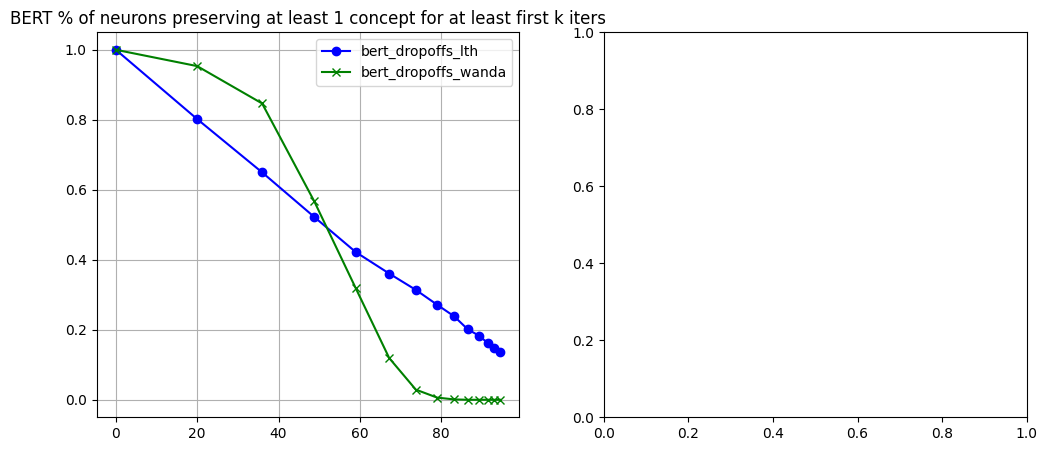

In [157]:
import torch
def get_neurons_explained_originally(model, method, filename):
    unique_concepts=set()
    explanations = {}
    cluster3_expls = pd.read_csv(f"/workspace/CCE_NLI/{model}/exp/{method}/{filename}/Expls/{0.0}%Pruned/Cluster3IOUS1024N.csv")
    all_concept_at_original = get_indiv_concepts_per_unit(cluster3_expls) 
    return len(list(all_concept_at_original.keys()))

def get_sparsity_list(model, method, filename):
    sparsities = []
    sparsity_list = sorted(os.listdir(f"/workspace/CCE_NLI/{model}/exp/{method}/{filename}/Expls/"))
    for sparsity in sparsity_list:
        if '.ipy' in sparsity: continue
        sparsity = sparsity.split("%")[0]
        sparsities.append(float(sparsity))
    return sorted(sparsities)
        
def dropoff(method, filename, k, **kwargs):
    sparsity_list = get_sparsity_list(model, method, filename)
    num_orig_neurons = kwargs['num_orig_neurons']
    concept_and_assoc_sparsities = kwargs['concept_assoc_sparsity']
    sparsity_mapping = kwargs['neuron_concept_sparsity_mapping']
    neurons_preserved = [False for i in range(num_orig_neurons)]
    for i,neuron in enumerate(sparsity_mapping.keys()):
        for concept in concept_and_assoc_sparsities[neuron]:
            list_of_concepts_and_sprsty = list(concept_and_assoc_sparsities[neuron][concept])
            first_k_iters_present = sorted(list_of_concepts_and_sprsty)[:k]
            if first_k_iters_present == sparsity_list[:k]: #this concept is preserved for at lesat the first 6 iters
                neurons_preserved[i] = True
                break
    return torch.where(torch.tensor(neurons_preserved)==1, 1,0).sum()/num_orig_neurons


    
    
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
x=[SPARSITY_RATIOS_WANDA[i] for i in range(0,14)] 

model="BERT"
bert_dropoffs_lth = []
method = 'lottery_ticket'
filename = 'Run2Full'
sparsity_list = SPARSITY_RATIOS_LTH
for k in range(1,15):
    num_orig_neurons = get_neurons_explained_originally(model, method, filename)
    neuron_concept_sparsity_mapping = get_concepts_across_pruning_per_neuron(model, method, filename)
    concept_assoc_sparsity=get_concepts_assoc_sparsities(model, method, filename)
    percent_of_concepts_preserved = dropoff(method, filename, k, num_orig_neurons=num_orig_neurons, concept_assoc_sparsity= concept_assoc_sparsity,neuron_concept_sparsity_mapping=neuron_concept_sparsity_mapping)
    bert_dropoffs_lth.append(percent_of_concepts_preserved)
    
    
bert_dropoffs_wanda = []
method = 'wanda'
filename = 'Run2Full'
sparsity_list = SPARSITY_RATIOS_WANDA
for k in range(1,15):
    num_orig_neurons = get_neurons_explained_originally(model, method, filename)
    neuron_concept_sparsity_mapping = get_concepts_across_pruning_per_neuron(model, method, filename)
    concept_assoc_sparsity=get_concepts_assoc_sparsities(model, method, filename)
    percent_of_concepts_preserved = dropoff(method, filename, k, num_orig_neurons=num_orig_neurons, concept_assoc_sparsity= concept_assoc_sparsity,neuron_concept_sparsity_mapping=neuron_concept_sparsity_mapping)
    bert_dropoffs_wanda.append(percent_of_concepts_preserved)
    


axs[0].plot(x, bert_dropoffs_lth, label='bert_dropoffs_lth', color='blue',marker='o')
axs[0].plot(x, bert_dropoffs_wanda, label='bert_dropoffs_wanda', color='green',marker='x')
axs[0].set_title('BERT % of neurons preserving at least 1 concept for at least first k iters')
axs[0].legend()
axs[0].grid(True)



'''
model="BOWMAN"
bowman_dropoffs_lth = []
method = 'lottery_ticket'
filename = 'Run2Full'
sparsity_list = SPARSITY_RATIOS_LTH
for k in range(1,15):
    num_orig_neurons = get_neurons_explained_originally(model, method, filename)
    neuron_concept_sparsity_mapping = get_concepts_across_pruning_per_neuron(model, method, filename)
    concept_assoc_sparsity=get_concepts_assoc_sparsities(model, method, filename)
    percent_of_concepts_preserved = dropoff(method, filename, k, num_orig_neurons=num_orig_neurons, concept_assoc_sparsity= concept_assoc_sparsity,neuron_concept_sparsity_mapping=neuron_concept_sparsity_mapping)
    bowman_dropoffs_lth.append(percent_of_concepts_preserved)
    
    
bowman_dropoffs_wanda = []
method = 'wanda'
filename = 'Run2Full'
sparsity_list = SPARSITY_RATIOS_WANDA
for k in range(1,15):
    num_orig_neurons = get_neurons_explained_originally(model, method, filename)
    neuron_concept_sparsity_mapping = get_concepts_across_pruning_per_neuron(model, method, filename)
    concept_assoc_sparsity=get_concepts_assoc_sparsities(model, method, filename)
    percent_of_concepts_preserved = dropoff(method, filename, k, num_orig_neurons=num_orig_neurons, concept_assoc_sparsity= concept_assoc_sparsity,neuron_concept_sparsity_mapping=neuron_concept_sparsity_mapping)
    bowman_dropoffs_wanda.append(percent_of_concepts_preserved)
    

axs[1].plot(x, bowman_dropoffs_lth, label='bowman_dropoffs_lth', color='blue',marker='o')
axs[1].plot(x, bowman_dropoffs_wanda, label='bowman_dropoffs_wanda', color='green',marker='x')
axs[1].set_title('BOWMAN neurons preserving at least 1 concept for at least first k iters')
axs[1].legend()
axs[1].grid(True)'''



#65% of neurons preserve concepts for at least 3 pruning iters

# globally: % of concepts that are preserved in kth pruning iter compared to original

412 412
343 482
322 498
285 499
250 501
176 463
120 441
105 450
90 438
134 455
119 445
103 442
74 440
58 437
412 412
298 529
306 542
284 545
294 527
280 556
288 551
278 550
282 534
278 528
281 517
282 514
265 511
269 504
14 14
13 16
13 16
11 17
8 23
10 19
31 31
20 44
22 47
20 59
20 55
20 63
15 61
19 59
19 68
14 63
14 67
14 77
15 72
18 85


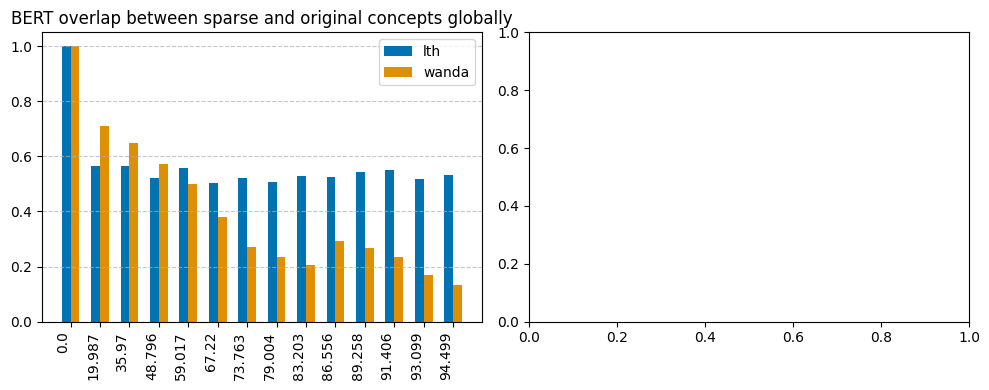

In [166]:
import os
import matplotlib.pyplot as plt

def get_concepts_across_cluster(model, method, filename):
    explanations = collections.defaultdict(set)
    sparsity_list = sorted(os.listdir(f"/workspace/CCE_NLI/{model}/exp/{method}/{filename}/Expls/"))
    for sparsity in sparsity_list:
        if '.ipy' in sparsity: continue
        sparsity = sparsity.split("%")[0]
        cluster3_expls = pd.read_csv(f"/workspace/CCE_NLI/{model}/exp/{method}/{filename}/Expls/{sparsity}%Pruned/Cluster3IOUS1024N.csv")
        for _,concepts in get_indiv_concepts_per_unit(cluster3_expls).items():
            explanations[float(sparsity)].update(concepts)
    return explanations
def overlap(cur, prev):
    intersection = len(cur.intersection(prev))
    union = len(cur.union(prev))
    print(intersection, union)
    return intersection / union if union > 0 else 0



fig, axs = plt.subplots(1, 2, figsize=(10, 4))  # 1 row, 2 columns

method='wanda'
filename='Run2Full'
model='BERT'
global_concepts = get_concepts_across_cluster(model,method, filename)
base_concepts = global_concepts[0.0]
bert_overlap_between_sparse_and_base_wanda= []
for sparsity in global_concepts:
    bert_overlap_between_sparse_and_base_wanda.append(overlap(global_concepts[sparsity], base_concepts))
    
method='lottery_ticket'
filename='Run2Full'
model='BERT'
global_concepts = get_concepts_across_cluster(model, method, filename)
base_concepts = global_concepts[0.0]
bert_overlap_between_sparse_and_base_lth= []
for sparsity in global_concepts:
    bert_overlap_between_sparse_and_base_lth.append(overlap(global_concepts[sparsity], base_concepts))
    
    
method='wanda'
filename='Run2Full'
model='BOWMAN'
global_concepts = get_concepts_across_cluster(model,method, filename)
base_concepts = global_concepts[0.0]
bowman_overlap_between_sparse_and_base_wanda= []
for sparsity in global_concepts:
    bowman_overlap_between_sparse_and_base_wanda.append(overlap(global_concepts[sparsity], base_concepts))
    
method='lottery_ticket'
filename='Run2Full'
model='BOWMAN'
global_concepts = get_concepts_across_cluster(model, method, filename)
base_concepts = global_concepts[0.0]
bowman_overlap_between_sparse_and_base_lth= []
for sparsity in global_concepts:
    bowman_overlap_between_sparse_and_base_lth.append(overlap(global_concepts[sparsity], base_concepts))
        
x=[SPARSITY_RATIOS_WANDA[i] for i in range(0,14)] 
x_pos = np.arange(len(x))  # Numeric positions for bars

bar_width = 0.3

# First plot
axs[0].bar(x_pos - bar_width/2, bert_overlap_between_sparse_and_base_lth, label='lth', color='#0173b2', width=bar_width)
axs[0].bar(x_pos + bar_width/2, bert_overlap_between_sparse_and_base_wanda, label='wanda', color='#de8f05', width=bar_width)
axs[0].set_title('BERT overlap between sparse and original concepts globally')
axs[0].legend()
axs[0].grid(True, axis='y', linestyle='--', alpha=0.7)
axs[0].set_xticks(x_pos)
axs[0].set_xticklabels(x, rotation=90, ha='right')

# Second plot
'''axs[1].plot(x[:6], bowman_overlap_between_sparse_and_base_lth[:6], label='lth',color='blue', marker='o')
axs[1].plot(x[:6], bowman_overlap_between_sparse_and_base_wanda, label='wanda',color='green', marker='x')
axs[1].set_title('BOWMAN overlap between sparse and original concepts globally')
axs[1].legend()'''

plt.tight_layout()
plt.show()


[Text(0, 0, '0.0'),
 Text(1, 0, '19.987'),
 Text(2, 0, '35.97'),
 Text(3, 0, '48.796'),
 Text(4, 0, '59.017'),
 Text(5, 0, '67.22'),
 Text(6, 0, '73.763'),
 Text(7, 0, '79.004'),
 Text(8, 0, '83.203'),
 Text(9, 0, '86.556'),
 Text(10, 0, '89.258'),
 Text(11, 0, '91.406'),
 Text(12, 0, '93.099'),
 Text(13, 0, '94.499')]

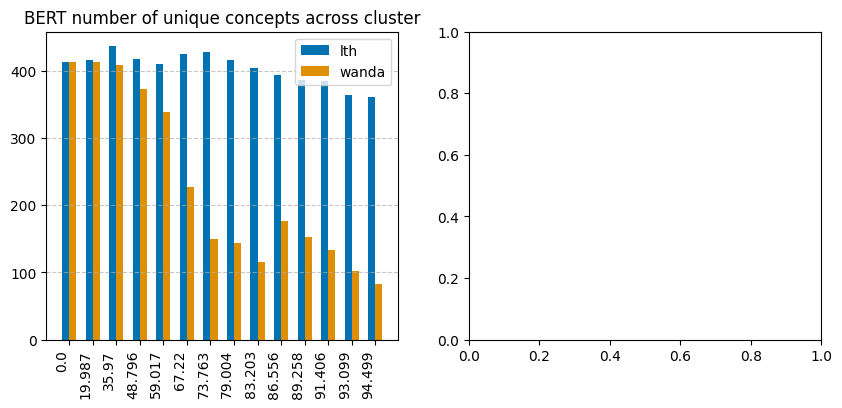

In [171]:
def get_number_of_unique_concepts_global(df):
    concepts=set()
    for neuron,expls in get_indiv_concepts_per_unit(df).items():
        concepts.update(expls)
    return len(concepts)

def get_num_concepts_across_cluster(model, method, filename):
    explanations = []
    sparsity_list = sorted(os.listdir(f"/workspace/CCE_NLI/{model}/exp/{method}/{filename}/Expls/"))
    for sparsity in sparsity_list:
        if '.ipy' in sparsity: continue
        sparsity = sparsity.split("%")[0]
        cluster3_expls = pd.read_csv(f"/workspace/CCE_NLI/{model}/exp/{method}/{filename}/Expls/{sparsity}%Pruned/Cluster3IOUS1024N.csv")
        num_unique = get_number_of_unique_concepts_global(cluster3_expls)
        explanations.append(num_unique)
    return explanations
import numpy as np

fig, axs = plt.subplots(1,2, figsize=(10, 4))  # 1 row, 2 columns
x_axis=[SPARSITY_RATIOS_WANDA[i] for i in range(0,14)]         
x_pos = np.arange(len(x_axis))  # Numeric positions for bars

bar_width = 0.3

model='BERT'
method='lottery_ticket'
filename='Run2Full'
# Plot grouped bars with offsets
axs[0].bar(x_pos - bar_width/2, get_num_concepts_across_cluster(model, method, filename), 
           label='lth', color='#0173b2', width=bar_width)

        
model='BERT'        
method='wanda'
filename='Run2Full'
axs[0].bar(x_pos + bar_width/2, get_num_concepts_across_cluster(model, method, filename), 
           label='wanda',color='#de8f05', width=bar_width)


axs[0].set_title('BERT number of unique concepts across cluster')
axs[0].legend()
axs[0].grid(True, axis='y', linestyle='--', alpha=0.7)
axs[0].set_xticks(x_pos)
axs[0].set_xticklabels(x, rotation=90, ha='right')


In [ ]:
#every iteration is 55% similar to the concepts in the original
#with wanda its expectedly reducing in similar (wb increase at 86)

# globally: % of concepts preserved in kth pruning iter compared to the one prior to it 

412 412
343 482
329 492
291 489
252 459
183 383
116 260
83 209
75 184
81 212
115 214
99 186
68 167
57 128
[0.0, 20.0, 36.0, 48.8, 59.04, 67.232, 73.786, 79.028, 83.223, 86.578, 89.263, 91.41, 93.128, 94.502]
412 412
298 529
314 537
319 534
307 519
296 537
311 540
300 543
290 530
301 497
291 489
289 481
275 473
273 452
14 14
13 16
14 16
12 17
8 23
9 23
31 31
20 44
23 48
23 63
23 69
19 77
24 73
21 71
26 77
23 79
24 72
24 86
25 91
30 98


[Text(0, 0, '0.0/0.0'),
 Text(1, 0, '0.0/19.987'),
 Text(2, 0, '19.987/35.97'),
 Text(3, 0, '35.97/48.796'),
 Text(4, 0, '48.796/59.017'),
 Text(5, 0, '59.017/67.22'),
 Text(6, 0, '67.22/73.763'),
 Text(7, 0, '73.763/79.004'),
 Text(8, 0, '79.004/83.203'),
 Text(9, 0, '83.203/86.556'),
 Text(10, 0, '86.556/89.258'),
 Text(11, 0, '89.258/91.406'),
 Text(12, 0, '91.406/93.099'),
 Text(13, 0, '93.099/94.499')]

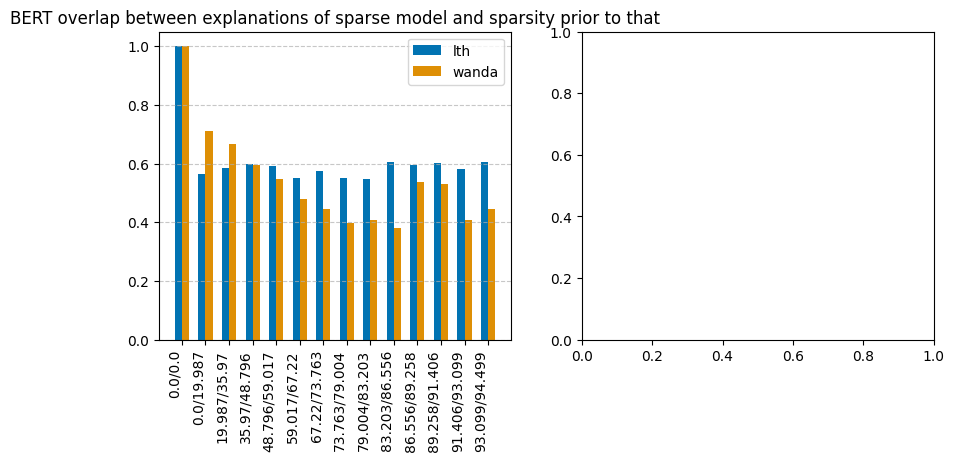

In [164]:
def get_concepts_across_cluster(model, method, filename):
    explanations = collections.defaultdict(set)
    sparsity_list = sorted(os.listdir(f"/workspace/CCE_NLI/{model}/exp/{method}/{filename}/Expls/"))
    for sparsity in sparsity_list:
        if '.ipy' in sparsity: continue
        sparsity = sparsity.split("%")[0]
        cluster3_expls = pd.read_csv(f"/workspace/CCE_NLI/{model}/exp/{method}/{filename}/Expls/{sparsity}%Pruned/Cluster3IOUS1024N.csv")
        for _,concepts in get_indiv_concepts_per_unit(cluster3_expls).items():
            explanations[float(sparsity)].update(concepts)
    return explanations

def overlap(cur, prev):
    intersection = len(cur.intersection(prev))
    union = len(cur.union(prev))
    print(intersection, union)
    return intersection / union if union > 0 else 0


fig, axs = plt.subplots(1,2, figsize=(10, 4))  # 1 row, 2 columns
import numpy as np
model='BERT'
method='wanda'
filename='Run2Full'
global_concepts = get_concepts_across_cluster(model, method, filename)

base_concepts = global_concepts[0.0]
sps = list(global_concepts.keys())

bert_overlap_between_sparse_and_base_wanda= []
for i,sparsity in enumerate(global_concepts.keys()):
    if i-1 >= 0:
        bert_overlap_between_sparse_and_base_wanda.append(overlap(global_concepts[sparsity], global_concepts[sps[i-1]]))
    else:
        bert_overlap_between_sparse_and_base_wanda.append(overlap(global_concepts[sparsity], base_concepts))
        
model='BERT'        
method='lottery_ticket'
filename='Run2Full'
global_concepts = get_concepts_across_cluster(model, method, filename)

base_concepts = global_concepts[0.0]
sps = list(global_concepts.keys())
bert_overlap_between_sparse_and_base_lth= []
print(sps)
for i,sparsity in enumerate(global_concepts.keys()):
    if i-1 >= 0:
        #print("Comparing sparsity ", sparsity, " with ", sps[i-1])
        bert_overlap_between_sparse_and_base_lth.append(overlap(global_concepts[sparsity], global_concepts[sps[i-1]]))
    else:
        bert_overlap_between_sparse_and_base_lth.append(overlap(global_concepts[sparsity], base_concepts))
     
model='BOWMAN'
method='wanda'
filename='Run2Full'
global_concepts = get_concepts_across_cluster(model, method, filename)

base_concepts = global_concepts[0.0]
sps = list(global_concepts.keys())
bowman_overlap_between_sparse_and_base_wanda= []
for i,sparsity in enumerate(global_concepts.keys()):
    if i-1 >= 0:
        bowman_overlap_between_sparse_and_base_wanda.append(overlap(global_concepts[sparsity], global_concepts[sps[i-1]]))
    else:
        bowman_overlap_between_sparse_and_base_wanda.append(overlap(global_concepts[sparsity], base_concepts))
        
model='BOWMAN'        
method='lottery_ticket'
filename='Run2Full'
global_concepts = get_concepts_across_cluster(model, method, filename)

base_concepts = global_concepts[0.0]
sps = list(global_concepts.keys())
bowman_overlap_between_sparse_and_base_lth= []
for i,sparsity in enumerate(global_concepts.keys()):
    if i-1 >= 0:
        #print("Comparing sparsity ", sparsity, " with ", sps[i-1])
        bowman_overlap_between_sparse_and_base_lth.append(overlap(global_concepts[sparsity], global_concepts[sps[i-1]]))
    else:
        bowman_overlap_between_sparse_and_base_lth.append(overlap(global_concepts[sparsity], base_concepts))
        
x_axis=[SPARSITY_RATIOS_WANDA[i] for i in range(0,14)]         
x = ["0.0/0.0"]+[f"{x_axis[j]}/{x_axis[j+1]}" for j in range(len(x_axis) - 1)]        
x_pos = np.arange(len(x))  # Numeric positions for bars

bar_width = 0.3

# Plot grouped bars with offsets
axs[0].bar(x_pos - bar_width/2, bert_overlap_between_sparse_and_base_lth, 
           label='lth', color='#0173b2', width=bar_width)

axs[0].bar(x_pos + bar_width/2, bert_overlap_between_sparse_and_base_wanda, 
           label='wanda',color='#de8f05', width=bar_width)

axs[0].set_title('BERT overlap between explanations of sparse model and sparsity prior to that')
axs[0].legend()
axs[0].grid(True, axis='y', linestyle='--', alpha=0.7)
axs[0].set_xticks(x_pos)
axs[0].set_xticklabels(x, rotation=90, ha='right')



# overlap: % of concepts in prev that carry over to next

cur= 0.0, pre= 0 
cur= 19.987, pre= 0.0 
cur= 35.97, pre= 19.987 
cur= 48.796, pre= 35.97 
cur= 59.017, pre= 48.796 
cur= 67.22, pre= 59.017 
cur= 73.763, pre= 67.22 
cur= 79.004, pre= 73.763 
cur= 83.203, pre= 79.004 
cur= 86.556, pre= 83.203 
cur= 89.258, pre= 86.556 
cur= 91.406, pre= 89.258 
cur= 93.099, pre= 91.406 
cur= 94.499, pre= 93.099 
[0.0, 20.0, 36.0, 48.8, 59.04, 67.232, 73.786, 79.028, 83.223, 86.578, 89.263, 91.41, 93.128, 94.502]
412 412
298 529
314 537
319 534
307 519
296 537
311 540
300 543
290 530
301 497
291 489
289 481
275 473
273 452
14 14
13 16
14 16
12 17
8 23
9 23
31 31
20 44
23 48
23 63
23 69
19 77
24 73
21 71
26 77
23 79
24 72
24 86
25 91
30 98


[Text(0, 0, '0.0/0.0'),
 Text(1, 0, '19.987/0.0'),
 Text(2, 0, '35.97/19.987'),
 Text(3, 0, '48.796/35.97'),
 Text(4, 0, '59.017/48.796'),
 Text(5, 0, '67.22/59.017'),
 Text(6, 0, '73.763/67.22'),
 Text(7, 0, '79.004/73.763'),
 Text(8, 0, '83.203/79.004'),
 Text(9, 0, '86.556/83.203'),
 Text(10, 0, '89.258/86.556'),
 Text(11, 0, '91.406/89.258'),
 Text(12, 0, '93.099/91.406'),
 Text(13, 0, '94.499/93.099')]

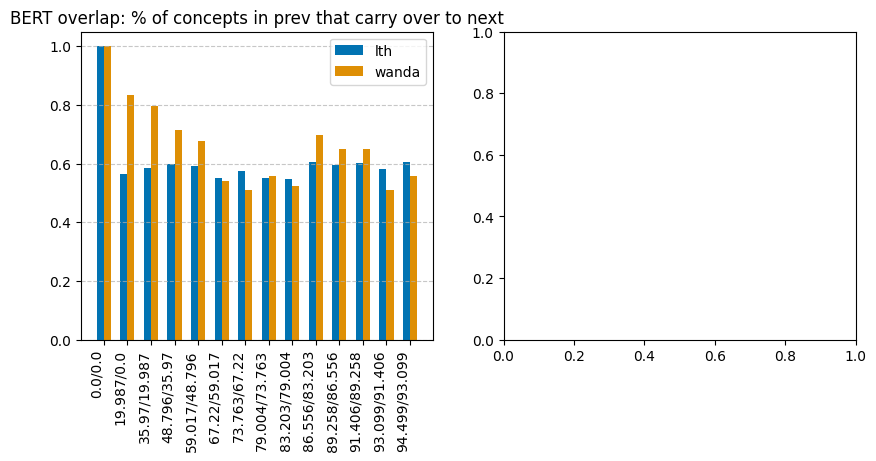

In [182]:
def get_concepts_across_cluster(model, method, filename):
    explanations = collections.defaultdict(set)
    sparsity_list = sorted(os.listdir(f"/workspace/CCE_NLI/{model}/exp/{method}/{filename}/Expls/"))
    for sparsity in sparsity_list:
        if '.ipy' in sparsity: continue
        sparsity = sparsity.split("%")[0]
        cluster3_expls = pd.read_csv(f"/workspace/CCE_NLI/{model}/exp/{method}/{filename}/Expls/{sparsity}%Pruned/Cluster3IOUS1024N.csv")
        for _,concepts in get_indiv_concepts_per_unit(cluster3_expls).items():
            explanations[float(sparsity)].update(concepts)
    return explanations

def entailement(cur, prev):
    ct=0
    for i in prev:
        if i in cur:
            ct +=1
    return ct/len(prev)


fig, axs = plt.subplots(1,2, figsize=(10, 4))  # 1 row, 2 columns
import numpy as np
model='BERT'
method='wanda'
filename='Run2Full'
global_concepts = get_concepts_across_cluster(model, method, filename)

base_concepts = global_concepts[0.0]
sps = list(global_concepts.keys())

bert_overlap_between_sparse_and_base_wanda= []
for i,sparsity in enumerate(global_concepts.keys()):
    
    if i-1 >= 0:
        
        print(f"cur= {sparsity}, pre= {sps[i-1]} ")
        bert_overlap_between_sparse_and_base_wanda.append(entailement(global_concepts[sparsity], global_concepts[sps[i-1]]))
    else:
        print(f"cur= {sparsity}, pre= 0 ")
        bert_overlap_between_sparse_and_base_wanda.append(entailement(global_concepts[sparsity],base_concepts))
        
model='BERT'        
method='lottery_ticket'
filename='Run2Full'
global_concepts = get_concepts_across_cluster(model, method, filename)

base_concepts = global_concepts[0.0]
sps = list(global_concepts.keys())
bert_overlap_between_sparse_and_base_lth= []
print(sps)
for i,sparsity in enumerate(global_concepts.keys()):
    if i-1 >= 0:
        #print("Comparing sparsity ", sparsity, " with ", sps[i-1])
        bert_overlap_between_sparse_and_base_lth.append(overlap(global_concepts[sparsity], global_concepts[sps[i-1]]))
    else:
        bert_overlap_between_sparse_and_base_lth.append(overlap(global_concepts[sparsity], base_concepts))
     
model='BOWMAN'
method='wanda'
filename='Run2Full'
global_concepts = get_concepts_across_cluster(model, method, filename)

base_concepts = global_concepts[0.0]
sps = list(global_concepts.keys())
bowman_overlap_between_sparse_and_base_wanda= []
for i,sparsity in enumerate(global_concepts.keys()):
    if i-1 >= 0:
        bowman_overlap_between_sparse_and_base_wanda.append(overlap(global_concepts[sparsity], global_concepts[sps[i-1]]))
    else:
        bowman_overlap_between_sparse_and_base_wanda.append(overlap(global_concepts[sparsity], base_concepts))
        
model='BOWMAN'        
method='lottery_ticket'
filename='Run2Full'
global_concepts = get_concepts_across_cluster(model, method, filename)

base_concepts = global_concepts[0.0]
sps = list(global_concepts.keys())
bowman_overlap_between_sparse_and_base_lth= []
for i,sparsity in enumerate(global_concepts.keys()):
    if i-1 >=0:
        #print("Comparing sparsity ", sparsity, " with ", sps[i-1])
        bowman_overlap_between_sparse_and_base_lth.append(overlap(global_concepts[sparsity], global_concepts[sps[i-1]]))
    else:
        bowman_overlap_between_sparse_and_base_lth.append(overlap(global_concepts[sparsity], base_concepts))
        
x_axis=[SPARSITY_RATIOS_WANDA[i] for i in range(0,14)]         
x = ["0.0/0.0"]+[f"{x_axis[j]}/{x_axis[j-1]}" for j in range(1,len(x_axis))]        
x_pos = np.arange(len(x))  # Numeric positions for bars

bar_width = 0.3

# Plot grouped bars with offsets
axs[0].bar(x_pos - bar_width/2, bert_overlap_between_sparse_and_base_lth, 
           label='lth', color='#0173b2', width=bar_width)

axs[0].bar(x_pos + bar_width/2, bert_overlap_between_sparse_and_base_wanda, 
           label='wanda',color='#de8f05', width=bar_width)

axs[0].set_title('BERT overlap: % of concepts in prev that carry over to next')
axs[0].legend()
axs[0].grid(True, axis='y', linestyle='--', alpha=0.7)
axs[0].set_xticks(x_pos)
axs[0].set_xticklabels(x, rotation=90, ha='right')



In [ ]:
#every subseq iteration has rougly 60% of concepts preserved fromthe prev iter lthbert